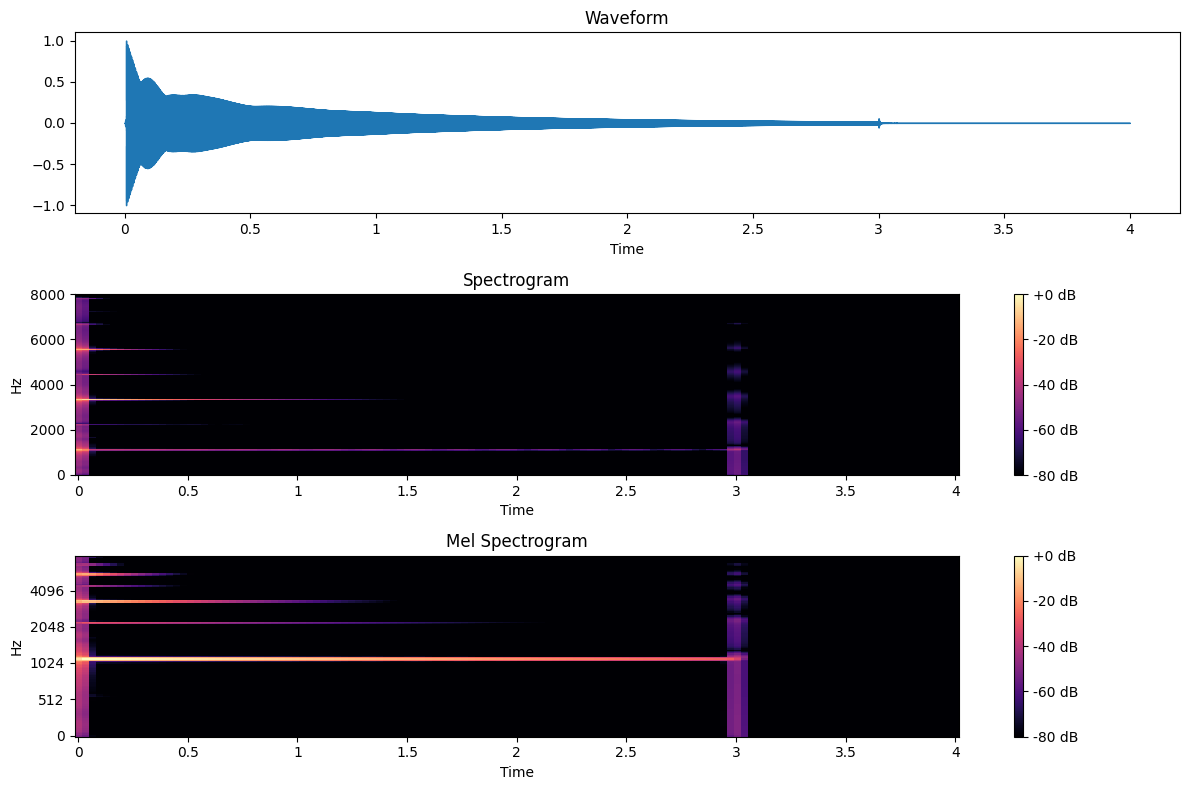

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ---------- Load audio ----------
audio_path = ".\comparaciones\guitar_electronic_og.wav"      # cambia esto
y, sr = librosa.load(audio_path, sr=None)

# ---------- Spectrogram ----------
D = np.abs(librosa.stft(y))

# ---------- Mel Spectrogram ----------
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

# ---------- Figure ----------
fig, ax = plt.subplots(3, 1, figsize=(12,8))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set_title("Waveform")

# Spectrogram
img1 = librosa.display.specshow(
    librosa.amplitude_to_db(D, ref=np.max),
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz",
    ax=ax[1]
)
ax[1].set_title("Spectrogram")
fig.colorbar(img1, ax=ax[1], format="%+2.f dB")

# Mel Spectrogram
img2 = librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    ax=ax[2]
)
ax[2].set_title("Mel Spectrogram")
fig.colorbar(img2, ax=ax[2], format="%+2.f dB")

plt.tight_layout()

plt.savefig(
    "waveform_spectrogram_mel.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

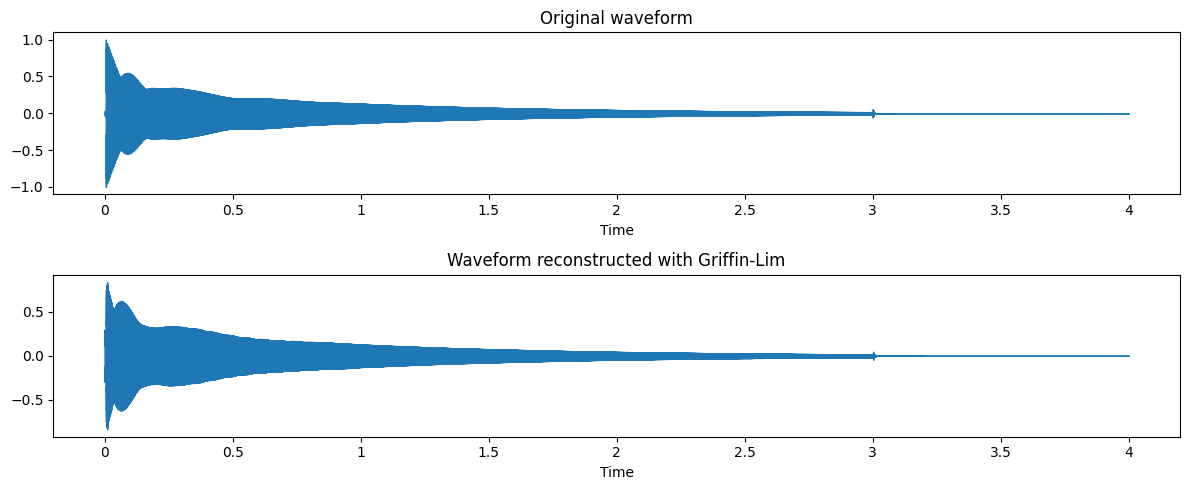

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


y, sr = librosa.load(audio_path, sr=None)

# STFT
stft = librosa.stft(y)

# Magnitude
mag = np.abs(stft)

# Griffin Lim reconstruction
reconstructed = librosa.griffinlim(
    mag,
    hop_length=512,
    n_iter=64
)

fig, ax = plt.subplots(2,1, figsize=(12,5))

librosa.display.waveshow(
    y,
    sr=sr,
    ax=ax[0]
)

ax[0].set_title("Original waveform")

librosa.display.waveshow(
    reconstructed,
    sr=sr,
    ax=ax[1]
)

ax[1].set_title("Waveform reconstructed with Griffin-Lim")

plt.tight_layout()

plt.savefig(
    "griffinlim_reconstruction.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()